In [3]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone your GitHub repo directly (easier than uploading from Drive)
import os
!git clone https://github.com/aikelind2609-cpu/brain-tumor-radiomics-cnn-fusion.git
os.chdir('/content/brain-tumor-radiomics-cnn-fusion')

# 3. Install dependencies
!pip install -q segment-anything
!pip install -q scikit-image mahotas xgboost shap streamlit joblib

# 4. Download SAM checkpoint
!mkdir -p models
!wget -q --show-progress https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O models/sam_vit_b_01ec64.pth

print("Setup done ✓")

Mounted at /content/drive
Cloning into 'brain-tumor-radiomics-cnn-fusion'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 67 (delta 16), reused 62 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 13.27 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (16/16), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 117.6 MB/s eta 0:00:00
models/sam_vit_b_01 100%[===================>] 357.67M   283MB/s    in 1.3s    
Setup done ✓


In [5]:
from pathlib import Path
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Point directly to the folder visible in your screenshot
RAW_DIR = Path('/content/drive/MyDrive/brain_tumor/raw')

# 3. Quick validation check to confirm it connects
if RAW_DIR.exists():
    print(f"✓ Successfully connected! Found your data directory at: {RAW_DIR}")
    # Print the subfolders inside (glioma, meningioma, etc.) to verify
    subdirs = [p.name for p in RAW_DIR.iterdir() if p.is_dir()]
    print(f"  Detected classes: {subdirs}")
else:
    print(f"✗ Path not found. Double check your folder name inside Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Successfully connected! Found your data directory at: /content/drive/MyDrive/brain_tumor/raw
  Detected classes: ['Training', 'Testing']


In [6]:
import os
os.chdir('/content/brain-tumor-radiomics-cnn-fusion')

# Remove any broken symlink
!rm -f data/raw

# Make the data directory and symlink Training + Testing separately
!mkdir -p data/raw
!ln -s /content/drive/MyDrive/brain_tumor/raw/Training data/raw/Training
!ln -s /content/drive/MyDrive/brain_tumor/raw/Testing data/raw/Testing

# Verify
!ls data/raw/
!ls data/raw/Training/

Testing  Training
glioma	meningioma  notumor  pituitary


In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


In [7]:
from segment_anything import sam_model_registry
sam = sam_model_registry['vit_b'](checkpoint='models/sam_vit_b_01ec64.pth')
sam.to('cuda')
sam.eval()
print("SAM loaded on GPU ✓")

SAM loaded on GPU ✓


In [11]:
#phase 2
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import gc
from pathlib import Path
from tqdm.notebook import tqdm
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

print("All imports done ✓")
print(f"GPU: {torch.cuda.get_device_name(0)}")

All imports done ✓
GPU: Tesla T4


In [9]:
os.chdir('/content/brain-tumor-radiomics-cnn-fusion')

PROCESSED_DIR = Path('data/processed/Training')
RAW_DIR       = Path('data/raw/Training')
MASK_DIR      = Path('tumor_masks/Training')
OUTPUT_DIR    = Path('outputs')

# Use processed if exists, else raw
DATA_DIR = PROCESSED_DIR if PROCESSED_DIR.exists() else RAW_DIR

CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Create output folders for each class
for cls in CLASSES:
    (MASK_DIR / cls).mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Source images : {DATA_DIR}")
print(f"Masks will be saved to : {MASK_DIR}")
print(f"Classes: {CLASSES}")

Source images : data/raw/Training
Masks will be saved to : tumor_masks/Training
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
CHECKPOINT = Path('models/sam_vit_b_01ec64.pth')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

sam = sam_model_registry['vit_b'](checkpoint=str(CHECKPOINT))
sam.to(DEVICE)
sam.eval()

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,          # full quality on GPU — was 8 on CPU
    pred_iou_thresh=0.80,
    stability_score_thresh=0.85,
    min_mask_region_area=100,    # filter out tiny noise regions
    output_mode='binary_mask',
)

print(f"SAM loaded on {DEVICE} ✓")

SAM loaded on cuda ✓


In [25]:
def extract_tumor_roi_morphological(image_gray):
    h, w = image_gray.shape

    # Skull strip — remove outer 10% ring
    skull_margin = int(min(h, w) * 0.10)
    skull_kernel = np.ones((skull_margin, skull_margin), np.uint8)
    brain_only   = cv2.erode(image_gray, skull_kernel, iterations=1)

    # Otsu threshold on brain-only
    _, thresh = cv2.threshold(brain_only, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological closing to fill holes
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, close_kernel, iterations=2)

    # Remove border-connected regions
    border_mask = np.zeros((h + 2, w + 2), np.uint8)
    filled = closed.copy()
    cv2.floodFill(filled, border_mask, (0, 0), 0)

    # Extra erosion to shrink large blobs — reduces whole-brain false positives
    shrink_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    filled = cv2.erode(filled, shrink_kernel, iterations=2)

    # Connected components — keep best inner region
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        filled, connectivity=8
    )

    margin = 0.15
    best_area, best_label = 0, -1

    for i in range(1, n_labels):
        area     = stats[i, cv2.CC_STAT_AREA]
        cy, cx   = centroids[i][1], centroids[i][0]
        area_pct = area / (h * w) * 100

        if (margin * h < cy < (1 - margin) * h and
            margin * w < cx < (1 - margin) * w and
            1.0 <= area_pct <= 12.0):   # tightened from 20 to 12

            if area > best_area:
                best_area  = area
                best_label = i

    if best_label == -1:
        return None, {'status': 'no_candidate'}

    result_mask = np.zeros_like(image_gray)
    result_mask[labels == best_label] = 255

    return result_mask, {
        'status'  : 'ok',
        'area_pct': round(best_area / (h * w) * 100, 2),
    }

print("extract_tumor_roi_morphological() updated ✓")

extract_tumor_roi_morphological() updated ✓


Info: {'status': 'ok', 'area_pct': np.float64(11.53)}


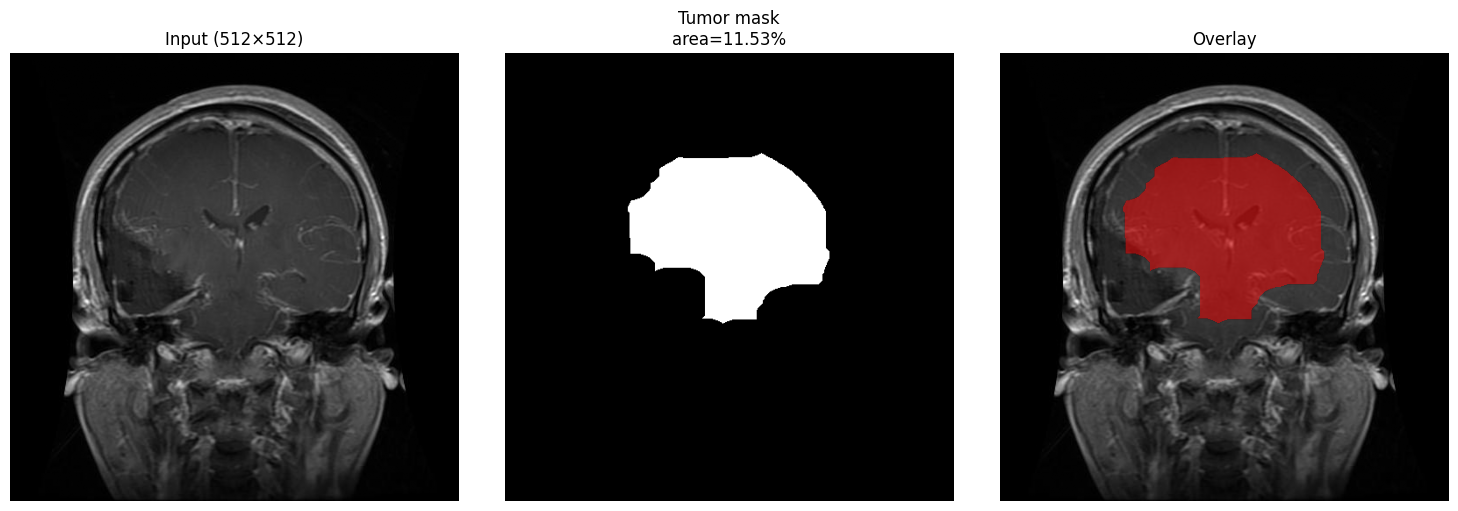

In [26]:
test_path = sorted((DATA_DIR / 'glioma').glob('*.jpg'))[0]
img_gray  = cv2.imread(str(test_path), cv2.IMREAD_GRAYSCALE)
img_512   = cv2.resize(img_gray, (512, 512))

tumor_mask, info = extract_tumor_roi_morphological(img_512)
print(f"Info: {info}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_512, cmap='gray')
axes[0].set_title('Input (512×512)')
axes[0].axis('off')

axes[1].imshow(tumor_mask if tumor_mask is not None
               else np.zeros_like(img_512), cmap='gray')
axes[1].set_title(f'Tumor mask\narea={info.get("area_pct","n/a")}%')
axes[1].axis('off')

axes[2].imshow(img_512, cmap='gray')
if tumor_mask is not None:
    overlay = np.zeros((*img_512.shape, 4))
    overlay[tumor_mask > 0] = [1, 0, 0, 0.5]
    axes[2].imshow(overlay)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('outputs/tumor_mask_morphological_test.png', dpi=120)
plt.show()

In [27]:
def process_class(cls, data_dir, mask_dir, img_size=512, save_size=224):
    src_dir = Path(data_dir) / cls
    dst_dir = Path(mask_dir) / cls
    dst_dir.mkdir(parents=True, exist_ok=True)

    images = sorted(src_dir.glob('*.png')) + sorted(src_dir.glob('*.jpg'))
    stats  = {'ok': 0, 'fallback': 0, 'failed': 0, 'total': len(images)}

    for img_path in tqdm(images, desc=f'{cls}', leave=False):
        dst_path = dst_dir / (img_path.stem + '_mask.png')
        if dst_path.exists():
            stats['ok'] += 1
            continue

        try:
            img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img_gray is None:
                stats['failed'] += 1
                continue

            img_resized = cv2.resize(img_gray, (img_size, img_size))
            tumor_mask, info = extract_tumor_roi_morphological(img_resized)

            if tumor_mask is None:
                # Fallback: Otsu whole-brain mask
                _, otsu = cv2.threshold(img_resized, 0, 255,
                                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                save_mask = cv2.resize(otsu, (save_size, save_size),
                                       interpolation=cv2.INTER_NEAREST)
                stats['fallback'] += 1
            else:
                save_mask = cv2.resize(tumor_mask, (save_size, save_size),
                                       interpolation=cv2.INTER_NEAREST)
                stats['ok'] += 1

            cv2.imwrite(str(dst_path), save_mask)

        except Exception as e:
            stats['failed'] += 1

    return stats


# Run on both splits
all_stats = {}
for split in ['Training', 'Testing']:
    data_split = Path(f'data/raw/{split}')
    mask_split = Path(f'tumor_masks/{split}')

    if not data_split.exists():
        print(f"Skipping {split} — not found")
        continue

    print(f"\n{'='*45}")
    print(f"  {split} split")
    print(f"{'='*45}")

    for cls in CLASSES:
        s = process_class(cls, data_split, mask_split)
        all_stats[f'{split}/{cls}'] = s
        print(f"  [{cls}] ok={s['ok']} | fallback={s['fallback']} "
              f"| failed={s['failed']} / {s['total']}")

print("\nBatch complete ✓")


  Training split


glioma:   0%|          | 0/1400 [00:00<?, ?it/s]

  [glioma] ok=821 | fallback=579 | failed=0 / 1400


meningioma:   0%|          | 0/1400 [00:00<?, ?it/s]

  [meningioma] ok=996 | fallback=404 | failed=0 / 1400


...

  [meningioma] ok=259 | fallback=141 | failed=0 / 400


notumor:   0%|          | 0/400 [00:00<?, ?it/s]

  [notumor] ok=169 | fallback=231 | failed=0 / 400


pituitary:   0%|          | 0/400 [00:00<?, ?it/s]

  [pituitary] ok=256 | fallback=144 | failed=0 / 400

Batch complete ✓


[glioma] total=1400 | fallbacks-in-sample=6/20 (30%)
[meningioma] total=1400 | fallbacks-in-sample=8/20 (40%)
[notumor] total=1400 | fallbacks-in-sample=7/20 (35%)
[pituitary] total=1400 | fallbacks-in-sample=6/20 (30%)


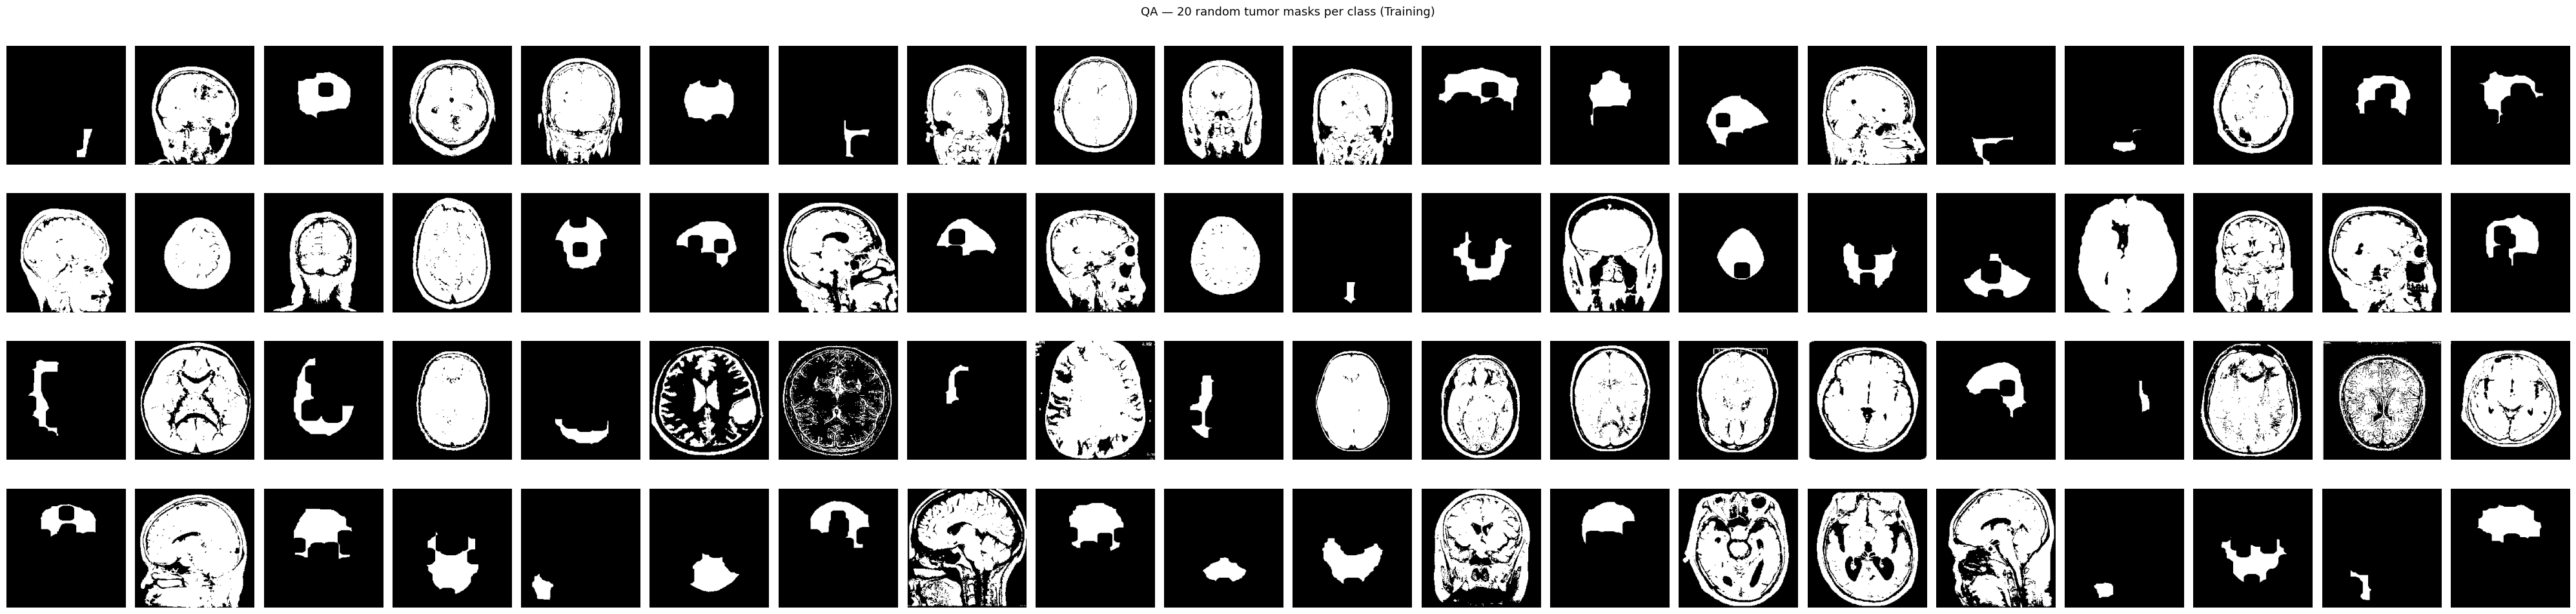


Fallback rate summary:
  glioma       30% ✓
  meningioma   40% ✓
  notumor      35% ✓
  pituitary    30% ✓


In [28]:
import random

fig, axes = plt.subplots(len(CLASSES), 20, figsize=(40, 10))
fig.suptitle('QA — 20 random tumor masks per class (Training)', fontsize=13)

failure_rates = {}

for row, cls in enumerate(CLASSES):
    mask_dir_cls = Path(f'tumor_masks/Training/{cls}')
    mask_files   = sorted(mask_dir_cls.glob('*_mask.png'))

    if len(mask_files) == 0:
        print(f"[{cls}] No masks found — skipping")
        continue

    sample    = random.sample(mask_files, min(20, len(mask_files)))
    fallbacks = 0

    for col, mf in enumerate(sample):
        mask = cv2.imread(str(mf), cv2.IMREAD_GRAYSCALE)

        # Fallback detection: if >40% of pixels are white = whole brain, not tumor
        if mask is not None and (mask > 0).mean() > 0.40:
            fallbacks += 1

        ax = axes[row][col]
        if mask is not None:
            ax.imshow(mask, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold')

    failure_rates[cls] = fallbacks / len(sample) * 100
    print(f"[{cls}] total={len(mask_files)} | "
          f"fallbacks-in-sample={fallbacks}/20 ({failure_rates[cls]:.0f}%)")

plt.tight_layout()
plt.savefig('outputs/mask_qa_morphological.png', dpi=80, bbox_inches='tight')
plt.show()

print("\nFallback rate summary:")
for cls, rate in failure_rates.items():
    flag = " ⚠ high — glioma heterogeneity expected" if rate > 40 else " ✓"
    print(f"  {cls:<12} {rate:.0f}%{flag}")

In [29]:
print("Backing up tumor_masks/ to Google Drive...")
!cp -r tumor_masks/ /content/drive/MyDrive/brain_tumor/
!cp -r outputs/ /content/drive/MyDrive/brain_tumor/
print("Backup complete ✓")
print("Saved to: /content/drive/MyDrive/brain_tumor/tumor_masks/")

Backing up tumor_masks/ to Google Drive...
Backup complete ✓
Saved to: /content/drive/MyDrive/brain_tumor/tumor_masks/


In [30]:
total, ok_total, fallback_total = 0, 0, 0
for key, s in all_stats.items():
    total         += s['total']
    ok_total      += s['ok']
    fallback_total += s['fallback']

print("=" * 50)
print("Phase 2 Checkpoint")
print("=" * 50)
print(f"Total images processed : {total}")
print(f"Tumor ROI found        : {ok_total}  ({ok_total/total*100:.1f}%)")
print(f"Otsu fallback used     : {fallback_total}  ({fallback_total/total*100:.1f}%)")
print()
print("Per split/class breakdown:")
for key, s in all_stats.items():
    print(f"  {key:<25} ok={s['ok']:<6} fallback={s['fallback']:<6} "
          f"failed={s['failed']}")
print()

masks_on_disk = sum(
    len(list(Path(f'tumor_masks/{split}/{cls}').glob('*_mask.png')))
    for split in ['Training', 'Testing']
    for cls in CLASSES
    if Path(f'tumor_masks/{split}/{cls}').exists()
)

print(f"Masks on disk : {masks_on_disk} / 7200")
if masks_on_disk >= 7000:
    print("\nPhase 2 COMPLETE ✓")
    print("Next → Phase 3: 04b_radiomics_tumor.ipynb")
else:
    print(f"\n⚠ {7200 - masks_on_disk} masks missing")
    print("Re-run Cell 6 — it skips already-done files automatically")

Phase 2 Checkpoint
Total images processed : 7200
Tumor ROI found        : 4261  (59.2%)
Otsu fallback used     : 2939  (40.8%)

Per split/class breakdown:
  Training/glioma           ok=821    fallback=579    failed=0
  Training/meningioma       ok=996    fallback=404    failed=0
  Training/notumor          ok=587    fallback=813    failed=0
  Training/pituitary        ok=945    fallback=455    failed=0
  Testing/glioma            ok=228    fallback=172    failed=0
  Testing/meningioma        ok=259    fallback=141    failed=0
  Testing/notumor           ok=169    fallback=231    failed=0
  Testing/pituitary         ok=256    fallback=144    failed=0

Masks on disk : 7200 / 7200

Phase 2 COMPLETE ✓
Next → Phase 3: 04b_radiomics_tumor.ipynb
